### Time Series Forecast Error 

Compare stability of different errors:

 - norm_mae = normalized_mean_absolute_error
 - norm_rmse = normalized_root_mean_squared_error
 - r2_score
 - spearman_correlation

How to Normalize?
 - by difference between maximum and minimum
 - by standard deviation of the "actual" curve
 - by mean value 
    - arbitrary, will differ if we shift the whole curve up or down
 - by interquartile range (i.e. the difference between 25th and 75th percentile)
    - arbitrary, will differ if we move points between quartile


In [2]:
import os, sys, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

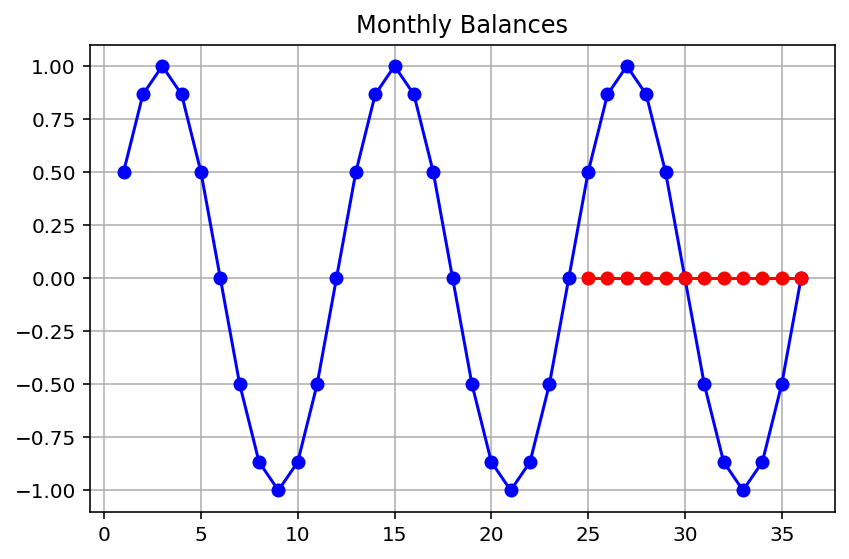

In [3]:
# suppose we have actual values for 3 years (36 months)
months = np.arange(1, 37, 1)
vals   = np.sin(months*2*math.pi/12.0)

# Suppose that we use first 24 months 
# to train a simple forecasting model.
# It is so trivial - it predicts zero values.

months_pred = np.arange(25, 37, 1)
vals_pred   = np.full(12,0)         # 12 points with 0 values 

fig, ax = plt.subplots(figsize=(6,4))
_ = ax.plot(months, vals, color="blue", marker='o')
_ = ax.plot(months_pred, vals_pred, color="red", marker='o')
_ = ax.set_title(f"Monthly Balances")
_ = ax.grid(True)

fig.tight_layout()
plt.show() ; # semicolon needed to remove text output on top

In [4]:
print(vals[24:].shape)
print(vals_pred.shape)

(12,)
(12,)


### error functions

In [5]:
# ----------------------------------------------------
def univ_err(actual, 
             predicted, 
             norm=None, 
             noise_level_relative=1e-4,
             noise_level_absolute=1e-4,
             max_error=1e4):
    """
    # calculate relative difference 
    # between two arrays (or lists): actual & predicted
    # univ_err() is similar to normalized_mean_absolute_error
    # but takes into account not only amplitude of oscillations,
    # but also the "level" of values.
    # It also limits maximum error in cases when 
    # actual signal doesn't change much
    # optional parameters:
    #   norm (when provided) used as denominator
    #   noise_level - relative , default 1e-4
    """
    Na, Np = len(actual), len(predicted)
    if Na == 0 or Np == 0 or Na != Np:
        return np.nan
    np_act = np.array(actual, dtype = np.float64)
    np_pre = np.array(predicted, dtype = np.float64)
    mean_abs_err = np.abs(np_act - np_pre).sum() / Na              
    if norm and norm > 0: # normalize - and limit
        return min (max_error, mean_abs_err / norm )  
    v_max_act, v_min_act = np.max(np_act), np.min(np_act) # max min   
    v_max_pre, v_min_pre = np.max(np_pre), np.min(np_pre) # max min  
    v_amp_act   = v_max_act - v_min_act        # amplitude      
    v_amp_pre   = v_max_pre - v_min_pre        # amplitude      
    v_level_act = np.abs(np_act).sum() / Na    # level             
    v_scale_act = max(v_level_act, v_amp_act)  # level
    v_level_pre = np.abs(np_pre).sum() / Na    # scale             
    v_scale_pre = max(v_level_pre, v_amp_pre)  # scale

    if (v_scale_act <= noise_level_absolute and 
        v_scale_pre <= noise_level_absolute):
            return 0 # actual and predicted are both close to zero 

    denom_min = max(mean_abs_err * noise_level_relative,
                    noise_level_absolute)
    
    if v_scale_act > denom_min :
        denom = v_scale_act
    else:
        denom = denom_min
    
    return min (max_error, (mean_abs_err / denom))

In [6]:
# ----------------------------------------------------
def mape (actual, predicted):
    """
    # calculate mape
    # (Mean Absolute Percentage Error)
    # between two arrays (or lists)
    """
    Na = len(actual)
    Np = len(predicted)
    if Na == 0 or Np == 0 or Na != Np:
        return np.nan
    actual_sum = np.absolute(actual).sum()
    if actual_sum <= 0:
        return np.nan
    mysum = 0
    for ii in range(Na):
        a = actual[ii]
        p = predicted[ii]
        c = a if np.abs(a) > 0.0001 else 0.0001
        v = np.abs((a-p)/c) / Na
        mysum += v
    return mysum

# ----------------------------------------------------
def myscale(x):
    """
    # find reasonable graph scale of positive variable
    """
    if x == 0:
        return 1e-6
    x = np.abs(x)
    n = 0    
    if 0 < x < 1:
        while x < 1:
            n+=1
            x *=10
    elif x >= 10:
        while x >= 10:
            n-=1
            x /=10
    x = 2 * round(x+1)
    return x * ( 10 ** (-n) )   

In [7]:
mytests = [
     ([0,0,0],[0,0,0]),
     ([1e-2,0,1e-3],[0,1e-2,0]),
     ([0,0,1.001],[0,0,1]),
     ([0,0,0.000],[2000,2,2]),
     ([0,0,0.001],[2000,2,2]),
     ([0,0,0.001],[0,0,0.001]),
     ([10,10,10],[0,0,0.00]),
     ([10,10,10],[0,0,0.001]),
     ([10,10,10],[10,10,10]),
     ([10,10,10],[10.2,10.3,10.2]),
]
for tup in mytests:
    print(tup, f"{univ_err(tup[0],tup[1]):.4f}")

([0, 0, 0], [0, 0, 0]) 0.0000
([0.01, 0, 0.001], [0, 0.01, 0]) 0.7000
([0, 0, 1.001], [0, 0, 1]) 0.0003
([0, 0, 0.0], [2000, 2, 2]) 10000.0000
([0, 0, 0.001], [2000, 2, 2]) 10000.0000
([0, 0, 0.001], [0, 0, 0.001]) 0.0000
([10, 10, 10], [0, 0, 0.0]) 1.0000
([10, 10, 10], [0, 0, 0.001]) 1.0000
([10, 10, 10], [10, 10, 10]) 0.0000
([10, 10, 10], [10.2, 10.3, 10.2]) 0.0233


### Error Function Selection

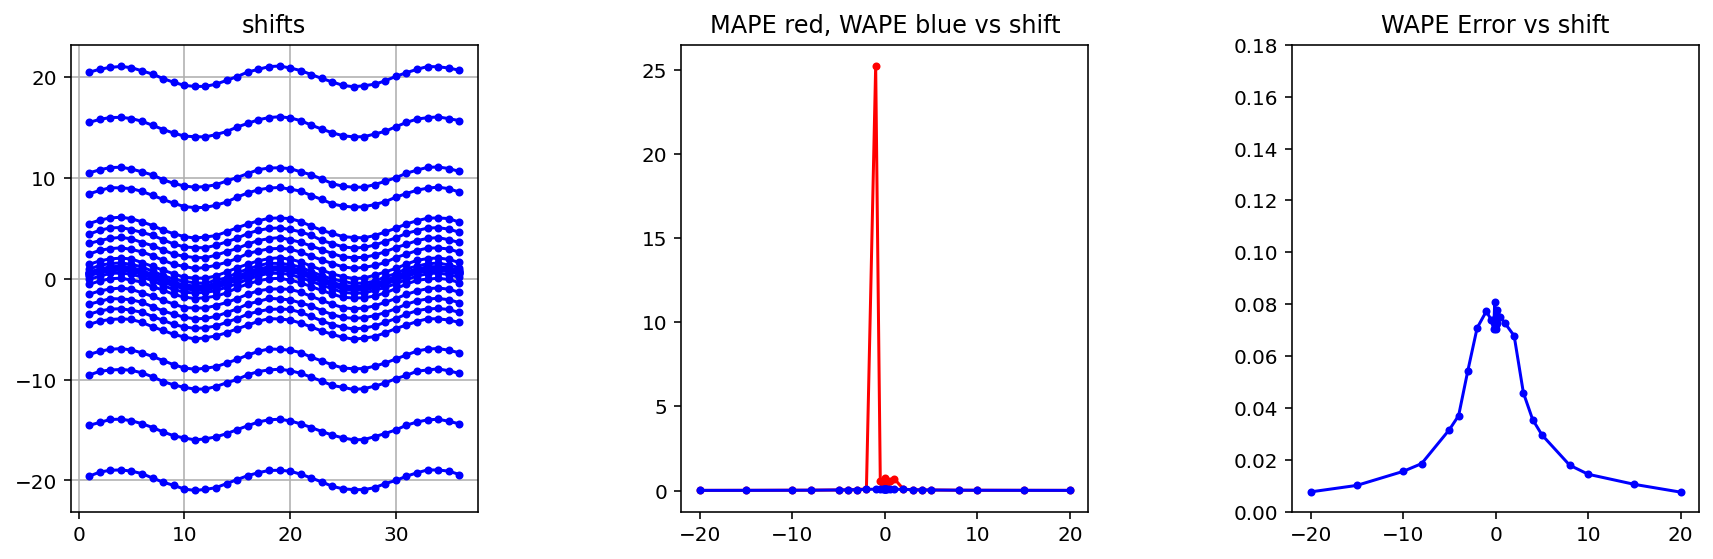

In [8]:
months = np.arange(1, 37, 1)
vals   = np.sin(months*2*math.pi/15.0)
levels = [-20,-15,-10,-8,-5,-4,-3,
          -2,-1,-0.5,-0.2,-0.1,0.05,0,0.05,0.1,0.2,0.5,1,2,
          3,4,5,8,10,15,20]

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))
ax0, ax1, ax2 = ax.flatten()

_ = ax0.set_title(f"shifts")
_ = ax1.set_title(f"MAPE red, WAPE blue vs shift")
_ = ax2.set_title(f"WAPE Error vs shift")
_ = ax0.grid(True)

errs_mape = []
errs_univ = []
for level in levels:
    rand_arr = 0.1*np.random.rand(len(vals))
    vals1 = vals+level+rand_arr
    vals2 = vals+level+0.2 # second ("predicted") curve shifted by 10% of amplitude
    errs_mape.append(round(mape(vals1,vals2),4))
    errs_univ.append(round(univ_err(vals1,vals2),4))
    _ = ax0.plot(months, vals1, color="blue", marker='.')  
    
_ = ax1.plot(levels, errs_mape, color="red" , marker='.')
_ = ax1.plot(levels, errs_univ, color="blue", marker='.')
_ = ax2.plot(levels, errs_univ, color="blue", marker='.')
_ = ax2.set(ylim=(0.0, myscale(np.max(errs_univ))))

fig.tight_layout()
plt.subplots_adjust(wspace=0.50, hspace=1.0)
plt.show() ; 

In [9]:
mape_max = np.max(errs_mape)
mape_min = np.min(errs_mape)
wape_max = np.max(errs_univ)
wape_min = np.min(errs_univ)

print(f"MAPE max/min = {mape_max:9.4f} / {mape_min:6.4f} = {(mape_max/mape_min):11,.4f}")
print(f"WAPE max/min = {wape_max:9.4f} / {wape_min:6.4f} = {(wape_max/wape_min):11,.4f}")

MAPE max/min =   25.2122 / 0.0075 =  3,361.6267
WAPE max/min =    0.0807 / 0.0075 =     10.7600


In [11]:
print("WAPE:")
for v in errs_univ:
    print(f"{v:.4f}", end=",")
print()
print("MAPE:")
for v in errs_mape:
    print(f"{v:.4f}", end=",")
print()

WAPE:
0.0076,0.0101,0.0155,0.0185,0.0316,0.0370,0.0544,0.0708,0.0773,0.0740,0.0703,0.0807,0.0750,0.0720,0.0705,0.0727,0.0777,0.0751,0.0727,0.0678,0.0458,0.0355,0.0296,0.0179,0.0144,0.0105,0.0075,
MAPE:
0.0076,0.0101,0.0157,0.0185,0.0323,0.0384,0.0578,0.0930,25.2122,0.5510,0.4211,0.4604,0.3931,0.7199,0.3489,0.3871,0.5519,0.5778,0.7096,0.0775,0.0476,0.0367,0.0304,0.0181,0.0145,0.0105,0.0075,
